## Publication review notice / Catatan review publikasi

This notebook retains previously executed outputs; it has not been rerun for this publication.
FIRMS dates use UTC, while the cached NASA POWER header uses LST. Matching date labels
does not align daily time windows. Weather correlations, lag analysis and weather panels
are PRE-ALIGNMENT EXPERIMENTS, not final PRD evidence. The regional weather mean also
uses a bounding box without a five-province land mask. Recompute after alignment and
spatial-domain review before interpreting these results.

Output lama belum dihitung ulang. Jangan kutip korelasi cuaca sebagai fakta PRD.
Skor prioritas tidak memakai cuaca atau sekolah; bobotnya tetap provisional.
Median sekolah 2,94 km dihitung atas baris grid-hari (jarak grid diulang pada tiap
tanggal aktif), bukan sekali per grid unik. Kedekatan bukan bukti dampak.
Dashboard adalah rancangan historis, bukan feed live atau alat operasional.
Read ../REVIEW_STATUS.md for the publication limitations.


# FIRELINE — Validasi Dataset Eksternal untuk MVP

**Status:** eksperimen pendukung; NASA FIRMS VIIRS NOAA-20 tetap menjadi dataset utama.

Notebook ini memeriksa apakah data cuaca eksternal benar-benar sejajar dengan FIRMS,
mengukur kelengkapan penggabungan data, dan mencari hubungan eksploratif yang layak
diuji lebih lanjut. Hasilnya bukan bukti sebab-akibat dan bukan model prediksi.

Outputnya membantu PMA menyusun narasi berbasis bukti, UX menentukan informasi pada
wireframe, dan SEA menyusun kontrak data konseptual. Notebook ini tidak membangun API.

In [1]:
from pathlib import Path
import json
import math
import time

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
for candidate in [Path.cwd(), Path.cwd().parent]:
    if (candidate / "fireline_hotspot_kalimantan_viirs_noaa20_2024_2026.csv").exists():
        ROOT = candidate
        break

PRIMARY_PATH = ROOT / "fireline_hotspot_kalimantan_viirs_noaa20_2024_2026.csv"
RAW_CACHE = ROOT / "data" / "external" / "raw" / "nasa_power"
OUTPUT_DIR = ROOT / "outputs" / "external_validation"
RAW_CACHE.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert PRIMARY_PATH.exists(), f"Dataset utama tidak ditemukan: {PRIMARY_PATH}"
print("Root:", ROOT)
print("Dataset utama:", PRIMARY_PATH)

Root: E:\DSA-FINAL\checkpoint_2\Fireline-eda-kaka
Dataset utama: E:\DSA-FINAL\checkpoint_2\Fireline-eda-kaka\fireline_hotspot_kalimantan_viirs_noaa20_2024_2026.csv


## 1. Acuan utama: NASA FIRMS

Satu baris FIRMS adalah observasi anomali panas oleh satelit, bukan satu kebakaran
lapangan yang sudah terverifikasi. Audit lengkap tetap berada di
EDA_FIRMS_Hotspot.ipynb; bagian ini hanya menetapkan periode dan wilayah eksperimen.

In [2]:
firms = pd.read_csv(PRIMARY_PATH)
firms["date"] = pd.to_datetime(firms["acq_date"], errors="coerce")

main_summary = pd.Series({
    "rows": len(firms),
    "columns": firms.shape[1],
    "date_min": firms["date"].min(),
    "date_max": firms["date"].max(),
    "missing_values": int(firms.isna().sum().sum()),
    "exact_duplicates": int(firms.duplicated().sum()),
    "latitude_min": firms["latitude"].min(),
    "latitude_max": firms["latitude"].max(),
    "longitude_min": firms["longitude"].min(),
    "longitude_max": firms["longitude"].max(),
})
display(main_summary.to_frame("value"))

full_dates = pd.date_range(firms["date"].min(), firms["date"].max(), freq="D")
daily_firms = (
    firms.groupby("date")
    .agg(
        detection_count=("date", "size"),
        frp_median=("frp", "median"),
        frp_max=("frp", "max"),
    )
    .reindex(full_dates)
    .rename_axis("date")
)
daily_firms["detection_count"] = daily_firms["detection_count"].fillna(0).astype(int)
display(daily_firms.head())

,value
rows,61583
columns,16
date_min,2024-08-01 00:00:00
date_max,2026-05-31 00:00:00
missing_values,0
exact_duplicates,0
latitude_min,-4.17349
latitude_max,4.35095
longitude_min,108.6836
longitude_max,119.49944


,detection_count,frp_median,frp_max
date,,,
2024-08-01,191,7.08,148.55
2024-08-02,5,3.06,3.37
2024-08-03,47,2.52,31.34
2024-08-04,256,6.33,123.87
2024-08-05,287,5.97,150.70


## 2. Dataset eksternal pertama: NASA POWER Daily

Variabel awal adalah presipitasi harian, suhu, kelembapan relatif, dan angin.
Periodenya mengikuti tanggal minimum dan maksimum FIRMS tanpa menggeser tahun.
NASA POWER beresolusi lebih kasar daripada grid produk 0,1 derajat, sehingga tahap
ini memakai ringkasan regional harian sebagai baseline.

In [3]:
POWER_URL = "https://power.larc.nasa.gov/api/temporal/daily/regional"
PARAMETERS = ["PRECTOTCORR", "T2M", "RH2M", "WS2M"]
START = firms["date"].min().strftime("%Y%m%d")
END = firms["date"].max().strftime("%Y%m%d")

DATE_SEGMENTS = []
segment_start = firms["date"].min()
while segment_start <= firms["date"].max():
    segment_end = min(segment_start + pd.Timedelta(days=365), firms["date"].max())
    DATE_SEGMENTS.append(
        (segment_start.strftime("%Y%m%d"), segment_end.strftime("%Y%m%d"))
    )
    segment_start = segment_end + pd.Timedelta(days=1)

LAT_MIN = math.floor(firms["latitude"].min() * 2) / 2
LAT_MAX = math.ceil(firms["latitude"].max() * 2) / 2
LON_MIN = math.floor(firms["longitude"].min() * 2) / 2
LON_MAX = math.ceil(firms["longitude"].max() * 2) / 2
LON_SEGMENTS = [(LON_MIN, min(LON_MIN + 10, LON_MAX))]
if LON_SEGMENTS[0][1] < LON_MAX:
    # Regional API mensyaratkan lebar minimum 2 derajat. Segmen terakhir
    # boleh overlap; duplikat koordinat-tanggal dibuang setelah normalisasi.
    second_start = min(LON_SEGMENTS[0][1], LON_MAX - 2)
    LON_SEGMENTS.append((second_start, LON_MAX))

print({
    "start": START,
    "end": END,
    "date_segments": DATE_SEGMENTS,
    "lat": (LAT_MIN, LAT_MAX),
    "lon_segments": LON_SEGMENTS,
})


def fetch_power(parameter, period_start, period_end, lon_min, lon_max, refresh=False):
    cache_name = (
        f"{parameter}_{period_start}_{period_end}_{lon_min}_{lon_max}.json"
        .replace(".", "p")
    )
    cache_path = RAW_CACHE / cache_name
    if cache_path.exists() and not refresh:
        return json.loads(cache_path.read_text(encoding="utf-8"))

    query = {
        "latitude-min": LAT_MIN,
        "latitude-max": LAT_MAX,
        "longitude-min": lon_min,
        "longitude-max": lon_max,
        "parameters": parameter,
        "community": "AG",
        "start": period_start,
        "end": period_end,
        "format": "JSON",
    }
    response = requests.get(POWER_URL, params=query, timeout=180)
    response.raise_for_status()
    payload = response.json()
    cache_path.write_text(json.dumps(payload), encoding="utf-8")
    time.sleep(0.4)
    return payload


payloads = []
for parameter in PARAMETERS:
    for period_start, period_end in DATE_SEGMENTS:
        for lon_min, lon_max in LON_SEGMENTS:
            payloads.append((
                parameter,
                fetch_power(
                    parameter,
                    period_start,
                    period_end,
                    lon_min,
                    lon_max,
                ),
            ))

print(f"Berhasil memuat {len(payloads)} respons regional NASA POWER.")

{'start': '20240801', 'end': '20260531', 'date_segments': [('20240801', '20250801'), ('20250802', '20260531')], 'lat': (-4.5, 4.5), 'lon_segments': [(108.5, 118.5), (117.5, 119.5)]}


C:\Users\Asus\AppData\Local\Temp\ipykernel_49496\3493507632.py:9: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  segment_end = min(segment_start + pd.Timedelta(days=365), firms["date"].max())
C:\Users\Asus\AppData\Local\Temp\ipykernel_49496\3493507632.py:13: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  segment_start = segment_end + pd.Timedelta(days=1)


Berhasil memuat 16 respons regional NASA POWER.


In [4]:
records = []
for parameter, payload in payloads:
    for feature in payload.get("features", []):
        longitude, latitude, *_ = feature["geometry"]["coordinates"]
        values = feature["properties"]["parameter"][parameter]
        for date_text, value in values.items():
            records.append({
                "date": pd.to_datetime(date_text, format="%Y%m%d"),
                "latitude": latitude,
                "longitude": longitude,
                "parameter": parameter,
                "value": np.nan if value == -999 else value,
            })

weather_long = pd.DataFrame(records).drop_duplicates(
    ["date", "latitude", "longitude", "parameter"], keep="first"
)
weather_grid = (
    weather_long.pivot_table(
        index=["date", "latitude", "longitude"],
        columns="parameter",
        values="value",
        aggfunc="first",
    )
    .reset_index()
)

weather_quality = pd.DataFrame({
    "rows": [len(weather_grid)],
    "weather_cells": [weather_grid[["latitude", "longitude"]].drop_duplicates().shape[0]],
    "date_min": [weather_grid["date"].min()],
    "date_max": [weather_grid["date"].max()],
    "duplicate_cell_dates": [
        int(weather_grid.duplicated(["date", "latitude", "longitude"]).sum())
    ],
    "missing_values": [int(weather_grid[PARAMETERS].isna().sum().sum())],
})
display(weather_quality)

,rows,weather_cells,date_min,date_max,duplicate_cell_dates,missing_values
0,228798,342,2024-08-01,2026-05-31,0,0


## 3. Penggabungan tingkat hari dan uji jeda

Cuaca pada lag 7 berarti cuaca tujuh hari sebelumnya dibandingkan dengan jumlah
observasi FIRMS hari ini. Korelasi mendekati +1 berarti pola bergerak searah,
mendekati -1 berarti berlawanan, dan mendekati 0 berarti tidak tampak hubungan
monoton yang kuat. Ini belum merupakan evaluasi prediksi.

,coverage_percent
PRECTOTCORR,100.0
T2M,100.0
RH2M,100.0
WS2M,100.0


,feature,lag_days,spearman_correlation,n_days
20,PRECTOTCORR_7d,0,-0.616693,663
10,RH2M,0,-0.578785,669
0,PRECTOTCORR,0,-0.568253,669
1,PRECTOTCORR,1,-0.562314,668
21,PRECTOTCORR_7d,1,-0.556894,662
11,RH2M,1,-0.546262,668
22,PRECTOTCORR_7d,3,-0.454235,660
12,RH2M,3,-0.444869,666
2,PRECTOTCORR,3,-0.441234,666
5,T2M,0,0.407843,669


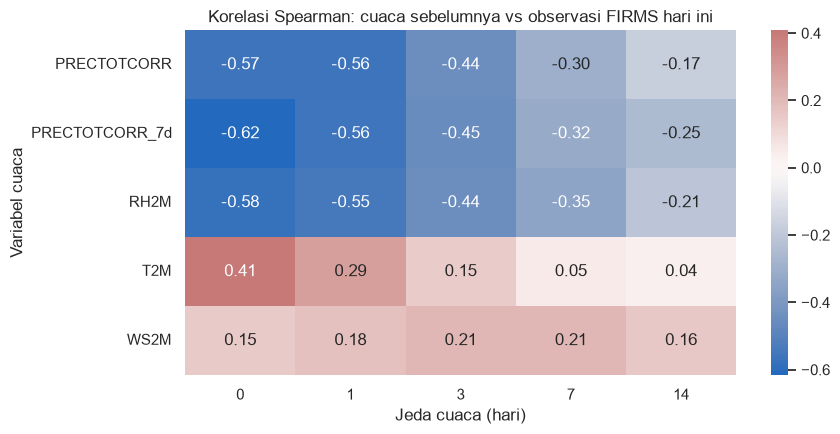

In [5]:
weather_daily = weather_grid.groupby("date")[PARAMETERS].mean().sort_index()
weather_daily["PRECTOTCORR_7d"] = weather_daily["PRECTOTCORR"].rolling(
    7, min_periods=7
).sum()

daily_join = daily_firms.join(weather_daily, how="left")
coverage = daily_join[PARAMETERS].notna().mean().mul(100).round(2)
display(coverage.rename("coverage_percent").to_frame())

LAGS = [0, 1, 3, 7, 14]
weather_features = PARAMETERS + ["PRECTOTCORR_7d"]
correlation_rows = []
for feature in weather_features:
    for lag in LAGS:
        pair = pd.concat(
            [daily_join["detection_count"], daily_join[feature].shift(lag)],
            axis=1,
        ).dropna()
        correlation_rows.append({
            "feature": feature,
            "lag_days": lag,
            "spearman_correlation": pair.iloc[:, 0].corr(
                pair.iloc[:, 1], method="spearman"
            ),
            "n_days": len(pair),
        })

lag_correlations = pd.DataFrame(correlation_rows)
ranked_correlations = (
    lag_correlations.assign(abs_corr=lambda x: x["spearman_correlation"].abs())
    .sort_values("abs_corr", ascending=False)
    .drop(columns="abs_corr")
)
display(ranked_correlations.head(15))

fig, ax = plt.subplots(figsize=(9, 4.5))
corr_matrix = lag_correlations.pivot(
    index="feature", columns="lag_days", values="spearman_correlation"
)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Korelasi Spearman: cuaca sebelumnya vs observasi FIRMS hari ini")
ax.set_xlabel("Jeda cuaca (hari)")
ax.set_ylabel("Variabel cuaca")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weather_lag_correlations.png", dpi=160, bbox_inches="tight")
plt.show()

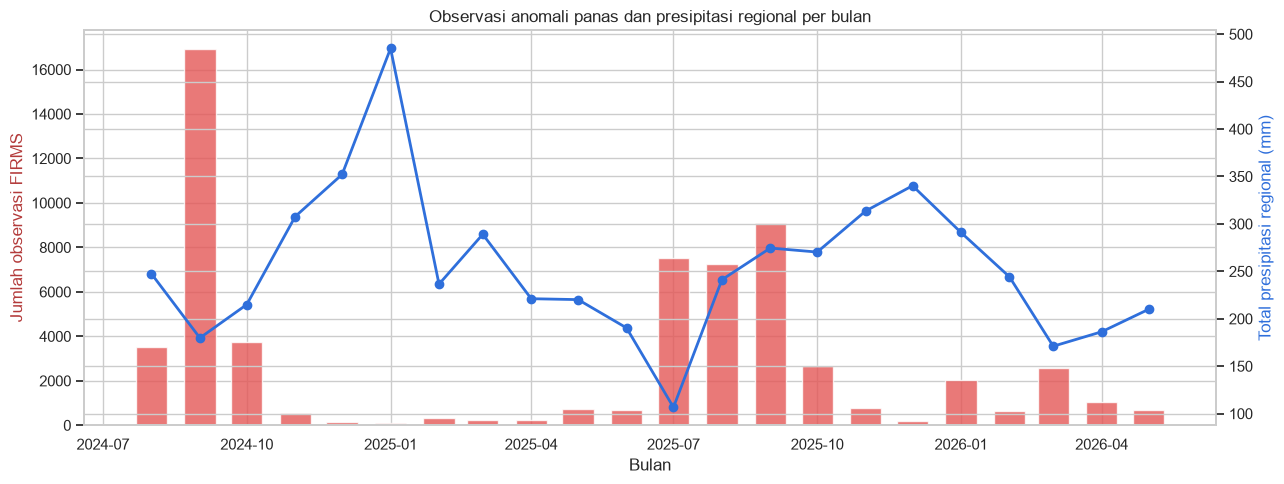

,detection_count,precipitation_mm,temperature_c,humidity_percent,wind_ms
date,,,,,
2024-08-01,3539,247.438977,26.711800,85.930535,1.845854
2024-09-01,16911,179.803772,27.045052,84.503341,1.862770
2024-10-01,3744,214.995877,27.022085,85.186541,1.531595
2024-11-01,534,307.783743,27.061915,85.615875,1.256293
2024-12-01,156,352.142573,26.713144,87.478030,1.720239
2025-01-01,124,485.002427,26.178497,88.815119,1.845430
2025-02-01,308,236.494269,26.178647,87.575626,1.730562
2025-03-01,252,289.062164,26.510823,86.863878,1.456046
2025-04-01,222,221.145088,26.762651,85.014551,1.107804


In [6]:
monthly = daily_join.resample("MS").agg(
    detection_count=("detection_count", "sum"),
    precipitation_mm=("PRECTOTCORR", "sum"),
    temperature_c=("T2M", "mean"),
    humidity_percent=("RH2M", "mean"),
    wind_ms=("WS2M", "mean"),
)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.bar(
    monthly.index,
    monthly["detection_count"],
    width=20,
    color="#e45756",
    alpha=0.8,
)
ax1.set_ylabel("Jumlah observasi FIRMS", color="#b33b3b")
ax1.set_xlabel("Bulan")
ax2 = ax1.twinx()
ax2.plot(
    monthly.index,
    monthly["precipitation_mm"],
    color="#2f6fdb",
    marker="o",
    linewidth=2,
)
ax2.set_ylabel("Total presipitasi regional (mm)", color="#2f6fdb")
ax1.set_title("Observasi anomali panas dan presipitasi regional per bulan")
fig.tight_layout()
plt.savefig(
    OUTPUT_DIR / "monthly_firms_vs_precipitation.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()
display(monthly)

## 4. Cara menyampaikan kepada tim

FIRMS tetap menjadi acuan utama untuk lokasi dan waktu observasi anomali panas.
NASA POWER hanya menambah konteks cuaca pada periode yang sama. Kami mengukur
kelengkapan join lalu melihat korelasi pada beberapa jeda waktu. Korelasi belum
membuktikan penyebab dan belum menjadikan MVP sebagai sistem prediksi. Untuk saat
ini output yang aman adalah peta dan antrean area verifikasi provisional.

- PMA memakai fakta audit untuk problem statement dan menandai manfaat sebagai hipotesis.
- UX menampilkan tanggal, area, observasi, confidence, FRP, cuaca, dan status data.
- SEA merancang struktur input-output konseptual berbasis grid_id + date.
- DSA menguji kualitas data dan generalisasi berbasis waktu sebelum menyebut prediksi.

In [7]:
weather_daily.to_csv(OUTPUT_DIR / "nasa_power_daily_regional.csv")
weather_grid.to_csv(OUTPUT_DIR / "nasa_power_grid_daily.csv", index=False)
daily_join.to_csv(OUTPUT_DIR / "firms_weather_daily_join.csv")
lag_correlations.to_csv(OUTPUT_DIR / "weather_lag_correlations.csv", index=False)

best = ranked_correlations.iloc[0]
summary = {
    "primary_rows": int(len(firms)),
    "period_start": str(firms["date"].min().date()),
    "period_end": str(firms["date"].max().date()),
    "weather_cells": int(
        weather_grid[["latitude", "longitude"]].drop_duplicates().shape[0]
    ),
    "minimum_weather_coverage_percent": float(coverage.min()),
    "strongest_exploratory_feature": str(best["feature"]),
    "strongest_exploratory_lag_days": int(best["lag_days"]),
    "strongest_exploratory_spearman": float(best["spearman_correlation"]),
    "claim_status": "exploratory_not_predictive",
}
(OUTPUT_DIR / "summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)
summary

{'primary_rows': 61583,
 'period_start': '2024-08-01',
 'period_end': '2026-05-31',
 'weather_cells': 342,
 'minimum_weather_coverage_percent': 100.0,
 'strongest_exploratory_feature': 'PRECTOTCORR_7d',
 'strongest_exploratory_lag_days': 0,
 'strongest_exploratory_spearman': -0.6166932525979133,
 'claim_status': 'exploratory_not_predictive'}